# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

\[
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
\]

где \(\sigma(z)\) — сигмоида:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

\[
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
\]

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [26]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
benign       357
malignant    212
Name: count, dtype: int64

Пропуски по признакам:


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64


Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


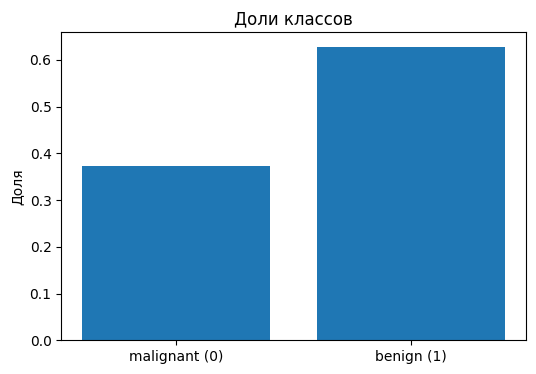

In [27]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [28]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [29]:
def sigmoid(z):
    # YOUR CODE HERE
    return 1/(1+np.exp(-z))

print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [30]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    y_pred_proba = np.clip(y_pred_proba, 1e-15, 1-1e-15)
    loss = -np.mean(
        np.log(y_pred_proba) * y_true + (1-y_true) * np.log(1-y_pred_proba)
    )
    return loss

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- \(\hat{p} = \sigma(z)\)

Градиенты для log-loss:
\[
dw = 
rac{1}{n} X^T(\hat{p} - y), \qquad db = 
rac{1}{n}\sum(\hat{p} - y)
\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [31]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    # 1) посчитать z
    # 2) посчитать p = sigmoid(z)
    # 3) посчитать loss
    # 4) посчитать dw и db
    z = X@w + b
    p = sigmoid(z)
    loss = compute_log_loss(y, p)
    dw = X.T @ (p-y)/X.shape[0]
    db = np.mean(p-y)
    return p, loss, dw, db

n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0




p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [32]:
class MyLogisticRegressionGD(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        i = 0
        for i in range(self.n_iters):
            p, loss, dw, db = forward_backward(X,y,self.w,self.b)
            self.loss_history.append(loss)
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        z = X @ self.w+self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds
    
    def score(self, X, y):
        # Метод для оценки качества (accuracy)
        predictions = self.predict(X)
        return np.mean(predictions == y)

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

Лучшие параметры: {'learning_rate': 0.05, 'n_iters': 500, 'threshold': 0.5}
Лучший score: 0.9780219780219781


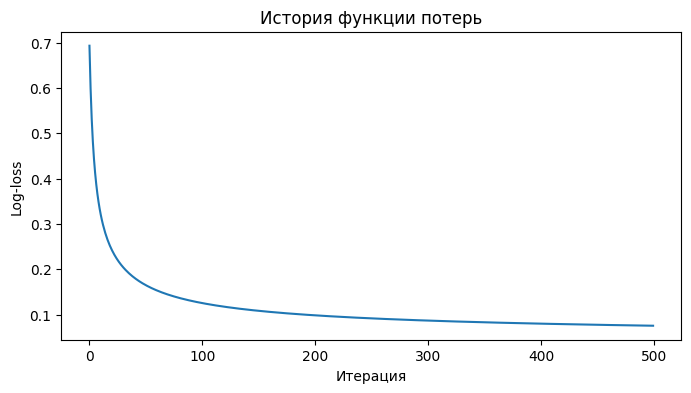

In [33]:
# YOUR CODE HERE
# обучите модель


my_model = MyLogisticRegressionGD(
    learning_rate=0.05,   # подберите разумное значение
    n_iters=100,         # задайте число итераций
    threshold=0.5
)
my_model.fit(X_train_scaled, y_train)
my_model.predict(X_test_scaled)


# подбор гиперпараметров
param_grid = {
    'learning_rate': [0.001,0.01, 0.05, 0.1],
    'n_iters': [50,100,500],
    'threshold': [0.2, 0.4, 0.5, 0.6]
}

my_model = MyLogisticRegressionGD()

grid_search = GridSearchCV(
    estimator=my_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_scaled, y_train)

print("Лучшие параметры:", grid_search.best_params_)
print("Лучший score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)



plt.figure(figsize=(8, 4))
plt.plot(best_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [34]:
# YOUR CODE HERE
my_proba_test = best_model.predict_proba(X_test_scaled)
my_pred_test = y_pred

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)

accuracy     0.9737
precision    0.9859
recall       0.9722
f1           0.9790
roc_auc      0.9957
dtype: float64

## Шаг 8. Confusion matrix и ROC-кривая

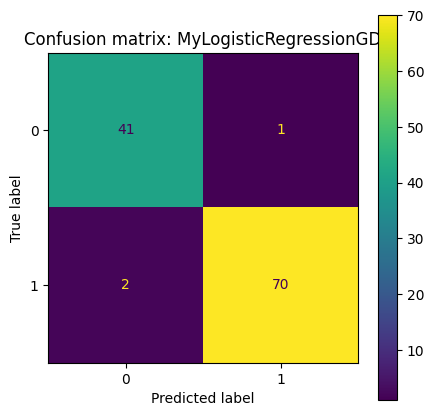

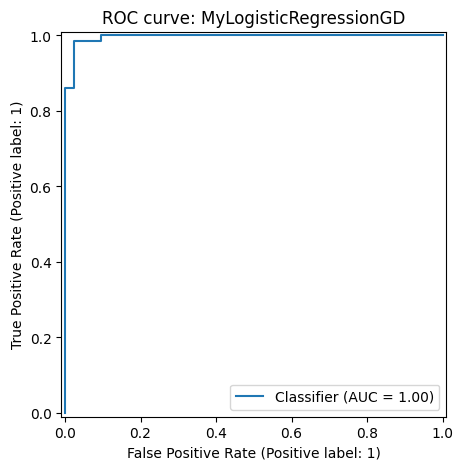

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [35]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [36]:
sk_model = LogisticRegression(max_iter=1000)

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите вероятности и классы на test
# 3) посчитайте те же метрики

sk_model.fit(X_train_scaled, y_train)
sk_y_proba_pred = sk_model.predict_proba(X_test_scaled)[:, 1]
sk_y_pred = sk_model.predict(X_test_scaled)



sk_metrics = {
    "accuracy": accuracy_score(y_test, sk_y_pred),
    "precision": precision_score(y_test, sk_y_pred),
    "recall": recall_score(y_test, sk_y_pred),
    "f1": f1_score(y_test, sk_y_pred),
    "roc_auc": roc_auc_score(y_test, sk_y_proba_pred),
}

pd.Series(sk_metrics).round(4)

accuracy     0.9825
precision    0.9861
recall       0.9861
f1           0.9861
roc_auc      0.9954
dtype: float64

## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [37]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": best_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9859,0.9722,0.9790,0.9957
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,-0.101819,0.648342,0.750160
21,worst texture,-0.618004,-1.255088,0.637084
10,radius error,-0.471160,-1.082965,0.611805
28,worst symmetry,-0.411068,-0.939181,0.528114
13,area error,-0.439083,-0.929104,0.490021
26,worst concavity,-0.367686,-0.823151,0.455465
15,compactness error,0.210540,0.647227,0.436686
27,worst concave points,-0.551225,-0.953686,0.402462
23,worst area,-0.566419,-0.947756,0.381337
20,worst radius,-0.596956,-0.947616,0.350660


## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [38]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr = (my_proba_test>=threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1": f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9649,0.9474,1.0000,0.9730
1,0.5,0.9737,0.9859,0.9722,0.9790
2,0.7,0.9211,0.9846,0.8889,0.9343


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. Почему для логистической регрессии используется сигмоида?
2. Почему в этой задаче мы считаем **log-loss**, а не MSE?
3. Зачем стандартизировать признаки перед обучением градиентным спуском?
4. Насколько близки метрики вашей реализации к `scikit-learn`?
5. Почему библиотечная модель обычно работает стабильнее и быстрее?
6. Как изменение порога влияет на precision и recall?
7. В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?

## Ответы на вопросы


1. Потому что задача логистической регрессии - предсказать вероятность, а не класс, а именно сигмоида ужимает значение функции в отрезок [0,1]

2. Потому что мы используем метод максимального правдоподобия, там при выводе формулы логарифмировали, чтобы избавиться от произведения, отсюда и логарифм

3. Если мы не будем стандартизировать признаки, то при расчете весов, может получиться так, что у одной фичи вес огромный, а у другой очень маленький, из-за этого некоторые признаки будут сильно доминировать, а другие вообще опускаться

4. Очень близки, различаются буквально на десятые доли процента, sklearn все таки немного лучше во всех метриках, кроме roc-auc

5. Она более оптимизирована на низком уровне

6. С повышением порога recall уменьшается, тк модель реже предсказывает положительный класс.

    А precision наоборот растет

7. Лог регрессия хороша, когда нужна интерпретируемость признаков(в банках например) и когда немного данных и они близки к линейным

    Лог регрессия уступает более сложным моделям при сложных нелинейных зависимостях в данных.


## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.

## Задание А

In [41]:
# Добавим L2

class MyLogisticRegressionRidgeGD(BaseEstimator, ClassifierMixin):
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5, lambda_reg=0.01):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.lambda_reg = lambda_reg
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        i = 0
        for i in range(self.n_iters):
            p, loss, dw, db = forward_backward(X,y,self.w,self.b)
            n_samples = X.shape[0]
            dw_reg = dw + (self.lambda_reg/n_samples) * self.w
            loss_reg = loss+ (self.lambda_reg/(2*n_samples))*np.sum(self.w**2)
            self.w = self.w - self.learning_rate * dw_reg
            self.b = self.b - self.learning_rate * db
            self.loss_history.append(loss_reg)
        return self

    def predict_proba(self, X):
        # YOUR CODE HERE
        z = X @ self.w+self.b
        proba = sigmoid(z)
        return proba

    def predict(self, X):
        # YOUR CODE HERE
        proba = self.predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds
    
    def score(self, X, y):
        # Метод для оценки качества (accuracy)
        predictions = self.predict(X)
        return np.mean(predictions == y)
    


    

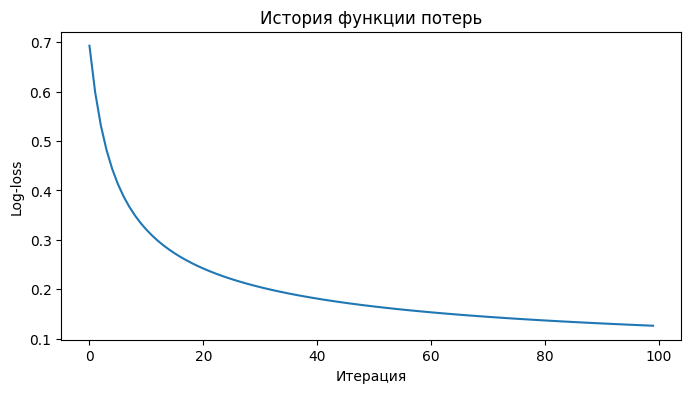

In [42]:
my_model_ridge = MyLogisticRegressionRidgeGD(
    learning_rate=0.05,   # подберите разумное значение
    n_iters=100,         # задайте число итераций
    threshold=0.5,
    lambda_reg=0.01
)
my_model_ridge.fit(X_train_scaled, y_train)
my_model_ridge.predict(X_test_scaled)

plt.figure(figsize=(8, 4))
plt.plot(my_model_ridge.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

In [44]:
ridge_y_proba_pred = my_model_ridge.predict_proba(X_test_scaled)
ridge_y_pred = my_model_ridge.predict(X_test_scaled)

ridge_metrics = {
    "accuracy": accuracy_score(y_test, ridge_y_pred),
    "precision": precision_score(y_test, ridge_y_pred),
    "recall": recall_score(y_test,ridge_y_pred),
    "f1": f1_score(y_test, ridge_y_pred),
    "roc_auc": roc_auc_score(y_test, ridge_y_proba_pred)
}

pd.Series(ridge_metrics).round(4)

accuracy     0.9561
precision    0.9589
recall       0.9722
f1           0.9655
roc_auc      0.9950
dtype: float64

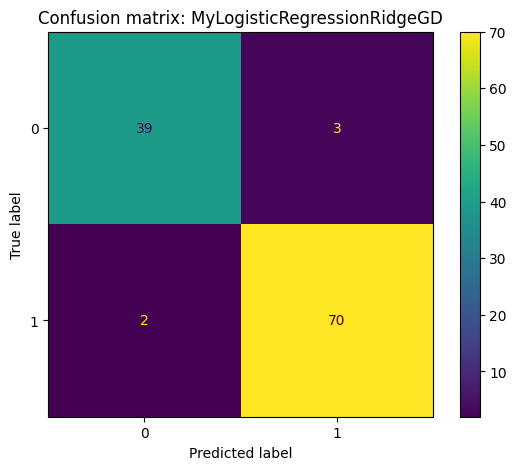

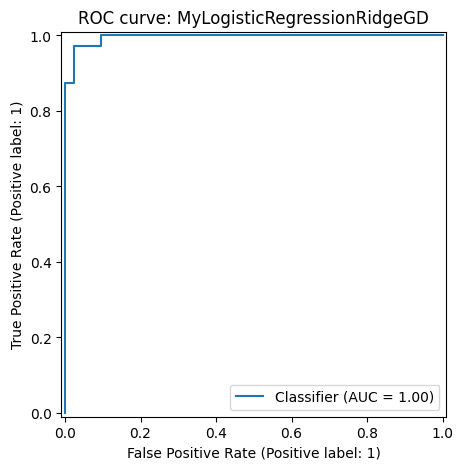

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [50]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, ridge_y_pred, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionRidgeGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, ridge_y_proba_pred, ax=ax)
plt.title("ROC curve: MyLogisticRegressionRidgeGD")
plt.show()

print(classification_report(y_test, my_pred_test))

In [49]:
compare_ridge = pd.DataFrame([my_metrics, sk_metrics, ridge_metrics], index=["my_model", "sklearn", "ridge"])
display(compare_ridge.round(4))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9737,0.9859,0.9722,0.9790,0.9957
sklearn,0.9825,0.9861,0.9861,0.9861,0.9954
ridge,0.9561,0.9589,0.9722,0.9655,0.9950
